In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import sys
import os
import warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
# Подавление предупреждений для чистоты вывода
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Добавляем корень проекта в sys.path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models import LinearRegressionCustom, RegularizedLinearRegression
from src.evaluate import calculate_metrics, evaluate_model

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Загрузка конфигурации
with open(PROJECT_ROOT / "config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# Загрузка обработанных данных
train_df = pd.read_json(config["paths"]["processed_train"])
test_df = pd.read_json(config["paths"]["processed_test"])

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")

Train: (16102, 44)
Test: (32277, 43)


## Автоматическое определение признаков

In [3]:
print("=" * 70)
print("ПОДГОТОВКА ДАННЫХ")
print("=" * 70)

# 1. Определение целевой переменной
target = "price"

# 2. Служебные колонки, которые не являются признаками
exclude_columns = [
    target,                  # целевая переменная
    "created",               # исходная дата (временные признаки уже извлечены)
    "features",              # сырой список удобств
    "features_cleaned",      # очищенный список удобств
    "interest_level",        # исходная категориальная колонка
    "num_features_raw",      # промежуточный признак
    "building_id",           # идентификатор здания (строковый)
]

# 3. Автоматическое извлечение признаков + фильтрация только числовых
feature_list = [
    col for col in train_df.columns
    if col not in exclude_columns
    and train_df[col].dtype in ['int64', 'float64']
]

# 4. Разделение на X и y
X_train = train_df[feature_list].copy()
y_train = train_df[target].copy()
X_test = test_df[feature_list].copy()
y_test = test_df[target].copy()

# 5. Масштабирование (для линейных моделей)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

# 6. Вывод информации
print(f"\nКоличество признаков: {len(feature_list)}")
print(f"Размер X_train: {X_train.shape}")
print(f"Размер X_test: {X_test.shape}")
print(f"\nСписок признаков:")
for i, feat in enumerate(feature_list, 1):
    print(f"  {i:2d}. {feat}")

print(f"\nТипы данных признаков:")
print(X_train.dtypes.value_counts())

print(f"\nПропуски в признаках:")
nulls = X_train.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "  Пропуски отсутствуют")

print(f"\nМасштабирование выполнено:")
print(f"  StandardScaler: X_train_std {X_train_std.shape}, X_test_std {X_test_std.shape}")
print(f"  MinMaxScaler:   X_train_mm {X_train_mm.shape}, X_test_mm {X_test_mm.shape}")
print(f"\nПримечание: деревьям решений (RF, XGBoost) масштабирование не требуется.")
print(f"Используйте X_train/X_test для деревьев, X_train_std/X_test_std для линейных моделей.")

ПОДГОТОВКА ДАННЫХ

Количество признаков: 32
Размер X_train: (16102, 32)
Размер X_test: (32277, 32)

Список признаков:
   1. bathrooms
   2. bedrooms
   3. latitude
   4. listing_id
   5. longitude
   6. elevator
   7. hardwoodfloors
   8. catsallowed
   9. dogsallowed
  10. doorman
  11. dishwasher
  12. laundryinbuilding
  13. nofee
  14. fitnesscenter
  15. laundryinunit
  16. pre-war
  17. roofdeck
  18. outdoorspace
  19. diningroom
  20. highspeedinternet
  21. balcony
  22. swimmingpool
  23. newconstruction
  24. loft
  25. terrace
  26. num_other_amenities
  27. num_amenities
  28. interest_level_encoded
  29. day_of_week
  30. month
  31. day
  32. is_weekend

Типы данных признаков:
int64      29
float64     3
Name: count, dtype: int64

Пропуски в признаках:
  Пропуски отсутствуют

Масштабирование выполнено:
  StandardScaler: X_train_std (16102, 32), X_test_std (32277, 32)
  MinMaxScaler:   X_train_mm (16102, 32), X_test_mm (32277, 32)

Примечание: деревьям решений (RF, XGBoos

## Инициализация таблиц результатов

In [4]:
# Инициализация таблиц для хранения результатов
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])
result_R2 = pd.DataFrame(columns=['model', 'train', 'test'])


def add_model_results(model_name, y_train_true, y_train_pred,
                      y_test_true, y_test_pred):
    """
    Вычисляет метрики и добавляет/обновляет результаты в таблицах.
    Если модель с таким именем уже существует — обновляет запись.
    """
    train_metrics = calculate_metrics(y_train_true, y_train_pred)
    test_metrics = calculate_metrics(y_test_true, y_test_pred)

    # Проверяем, существует ли уже запись с таким именем модели
    if model_name in result_MAE['model'].values:
        # Обновляем существующую запись
        result_MAE.loc[result_MAE['model'] == model_name, 'train'] = train_metrics['MAE']
        result_MAE.loc[result_MAE['model'] == model_name, 'test'] = test_metrics['MAE']
        
        result_RMSE.loc[result_RMSE['model'] == model_name, 'train'] = train_metrics['RMSE']
        result_RMSE.loc[result_RMSE['model'] == model_name, 'test'] = test_metrics['RMSE']
        
        result_R2.loc[result_R2['model'] == model_name, 'train'] = train_metrics['R2']
        result_R2.loc[result_R2['model'] == model_name, 'test'] = test_metrics['R2']
    else:
        # Добавляем новую запись
        result_MAE.loc[len(result_MAE)] = [model_name, train_metrics['MAE'], test_metrics['MAE']]
        result_RMSE.loc[len(result_RMSE)] = [model_name, train_metrics['RMSE'], test_metrics['RMSE']]
        result_R2.loc[len(result_R2)] = [model_name, train_metrics['R2'], test_metrics['R2']]

    print(f"  Train MAE: ${train_metrics['MAE']:.2f} | Test MAE: ${test_metrics['MAE']:.2f}")
    print(f"  Train R2:  {train_metrics['R2']:.4f} | Test R2:  {test_metrics['R2']:.4f}")

## Baseline модели (Naive)

In [5]:
from sklearn.dummy import DummyRegressor

# Naive Mean
print("[Naive Mean]")
naive_mean = DummyRegressor(strategy='mean')
naive_mean.fit(X_train, y_train)
add_model_results(
    'Naive_Mean',
    y_train, naive_mean.predict(X_train),
    y_test, naive_mean.predict(X_test)
)

# Naive Median
print("\n[Naive Median]")
naive_median = DummyRegressor(strategy='median')
naive_median.fit(X_train, y_train)
add_model_results(
    'Naive_Median',
    y_train, naive_median.predict(X_train),
    y_test, naive_median.predict(X_test)
)

[Naive Mean]
  Train MAE: $1119.81 | Test MAE: $1136.30
  Train R2:  0.0000 | Test R2:  -0.0009

[Naive Median]
  Train MAE: $1066.91 | Test MAE: $1096.55
  Train R2:  -0.0667 | Test R2:  -0.0799


## Custom Linear Regression (Analytical, Batch GD, SGD)

In [6]:
# 1. Analytical Solution (нормальное уравнение)
print("\n[Custom Analytical]")
model_analytical = LinearRegressionCustom(method='analytical', random_state=42)
model_analytical.fit(X_train_std, y_train)
add_model_results(
    'Custom_Analytical',
    y_train, model_analytical.predict(X_train_std),
    y_test, model_analytical.predict(X_test_std)
)

# 2. Batch Gradient Descent
print("\n[Custom Batch GD]")
model_batch_gd = LinearRegressionCustom(
    method='batch_gd',
    learning_rate=0.01,
    n_iterations=1000,
    random_state=42
)
model_batch_gd.fit(X_train_std, y_train)
add_model_results(
    'Custom_Batch_GD',
    y_train, model_batch_gd.predict(X_train_std),
    y_test, model_batch_gd.predict(X_test_std)
)

# 3. Stochastic Gradient Descent
print("\n[Custom SGD]")

model_sgd = LinearRegressionCustom(
    method='sgd',
    learning_rate=0.00001,
    n_iterations=10,
    random_state=42
)
model_sgd.fit(X_train_std, y_train)

# Проверка на наличие NaN в весах перед предсказанием (защитная мера)
if np.any(np.isnan(model_sgd.weights)) or np.isnan(model_sgd.bias):
    print("  Предупреждение: Веса модели содержат NaN. SGD не сошелся.")
else:
    add_model_results(
        'Custom_SGD',
        y_train, model_sgd.predict(X_train_std),
        y_test, model_sgd.predict(X_test_std)
    )


[Custom Analytical]
  Train MAE: $684.81 | Test MAE: $676.21
  Train R2:  0.5836 | Test R2:  0.6026

[Custom Batch GD]
  Train MAE: $689.33 | Test MAE: $680.09
  Train R2:  0.5821 | Test R2:  0.6117

[Custom SGD]
  Train MAE: $1095.58 | Test MAE: $1116.27
  Train R2:  -0.0175 | Test R2:  -0.0220


## Custom Regularized Models (Ridge, Lasso, ElasticNet)

In [7]:
# 1. Custom Ridge (аналитическое решение)
print("\n[Custom Ridge]")
custom_ridge = RegularizedLinearRegression(
    reg_type='ridge',
    alpha=1.0,
    random_state=42
)
custom_ridge.fit(X_train_std, y_train)
add_model_results(
    'Custom_Ridge',
    y_train, custom_ridge.predict(X_train_std),
    y_test, custom_ridge.predict(X_test_std)
)

# 2. Custom Lasso (градиентный спуск)
print("\n[Custom Lasso]")
custom_lasso = RegularizedLinearRegression(
    reg_type='lasso',
    alpha=0.1,
    learning_rate=0.001,
    n_iterations=10000,
    random_state=42
)
custom_lasso.fit(X_train_std, y_train)
add_model_results(
    'Custom_Lasso',
    y_train, custom_lasso.predict(X_train_std),
    y_test, custom_lasso.predict(X_test_std)
)

# 3. Custom ElasticNet (градиентный спуск)
print("\n[Custom ElasticNet]")
custom_elastic = RegularizedLinearRegression(
    reg_type='elastic',
    alpha=0.1,
    learning_rate=0.001,
    n_iterations=10000,
    random_state=42
)
custom_elastic.fit(X_train_std, y_train)
add_model_results(
    'Custom_ElasticNet',
    y_train, custom_elastic.predict(X_train_std),
    y_test, custom_elastic.predict(X_test_std)
)


[Custom Ridge]
  Train MAE: $684.82 | Test MAE: $676.21
  Train R2:  0.5836 | Test R2:  0.6027

[Custom Lasso]
  Train MAE: $689.32 | Test MAE: $680.10
  Train R2:  0.5821 | Test R2:  0.6118

[Custom ElasticNet]
  Train MAE: $688.86 | Test MAE: $679.66
  Train R2:  0.5809 | Test R2:  0.6106


## Sklearn модели

In [8]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# 1. Sklearn LinearRegression
print("[Sklearn LinearRegression]")
sklearn_lr = LinearRegression()
sklearn_lr.fit(X_train_std, y_train)
add_model_results(
    'Sklearn_LinearRegression',
    y_train, sklearn_lr.predict(X_train_std),
    y_test, sklearn_lr.predict(X_test_std)
)

# 2. Sklearn Ridge
print("\n[Sklearn Ridge]")
sklearn_ridge = Ridge(alpha=1.0, random_state=42)
sklearn_ridge.fit(X_train_std, y_train)
add_model_results(
    'Sklearn_Ridge',
    y_train, sklearn_ridge.predict(X_train_std),
    y_test, sklearn_ridge.predict(X_test_std)
)

# 3. Sklearn Lasso
print("\n[Sklearn Lasso]")
sklearn_lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
sklearn_lasso.fit(X_train_std, y_train)
add_model_results(
    'Sklearn_Lasso',
    y_train, sklearn_lasso.predict(X_train_std),
    y_test, sklearn_lasso.predict(X_test_std)
)

# 4. Sklearn ElasticNet
print("\n[Sklearn ElasticNet]")
sklearn_elastic = ElasticNet(alpha=0.1, random_state=42, max_iter=10000)
sklearn_elastic.fit(X_train_std, y_train)
add_model_results(
    'Sklearn_ElasticNet',
    y_train, sklearn_elastic.predict(X_train_std),
    y_test, sklearn_elastic.predict(X_test_std)
)

[Sklearn LinearRegression]
  Train MAE: $684.81 | Test MAE: $676.21
  Train R2:  0.5836 | Test R2:  0.6026

[Sklearn Ridge]
  Train MAE: $684.82 | Test MAE: $676.21
  Train R2:  0.5836 | Test R2:  0.6027

[Sklearn Lasso]
  Train MAE: $684.84 | Test MAE: $676.21
  Train R2:  0.5836 | Test R2:  0.6030

[Sklearn ElasticNet]
  Train MAE: $688.33 | Test MAE: $679.17
  Train R2:  0.5812 | Test R2:  0.6105


## Ансамблевые модели (RF, XGBoost, CatBoost)

In [9]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# 1. Random Forest (без масштабирования)
print("\n[Random Forest]")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
add_model_results(
    'RandomForest',
    y_train, rf_model.predict(X_train),
    y_test, rf_model.predict(X_test)
)

# 2. XGBoost (без масштабирования)
print("\n[XGBoost]")
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
add_model_results(
    'XGBoost',
    y_train, xgb_model.predict(X_train),
    y_test, xgb_model.predict(X_test)
)

# 3. CatBoost (поддерживает категориальные признаки нативно)
print("\n[CatBoost]")
cat_model = CatBoostRegressor(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    verbose=False,
    task_type='CPU'
)
cat_model.fit(X_train, y_train)
add_model_results(
    'CatBoost',
    y_train, cat_model.predict(X_train),
    y_test, cat_model.predict(X_test)
)


[Random Forest]
  Train MAE: $413.29 | Test MAE: $481.56
  Train R2:  0.8248 | Test R2:  0.7726

[XGBoost]
  Train MAE: $365.53 | Test MAE: $438.58
  Train R2:  0.8666 | Test R2:  0.8064

[CatBoost]
  Train MAE: $453.09 | Test MAE: $462.77
  Train R2:  0.7897 | Test R2:  0.7912


## Feature Importance


Лучшая модель: XGBoost


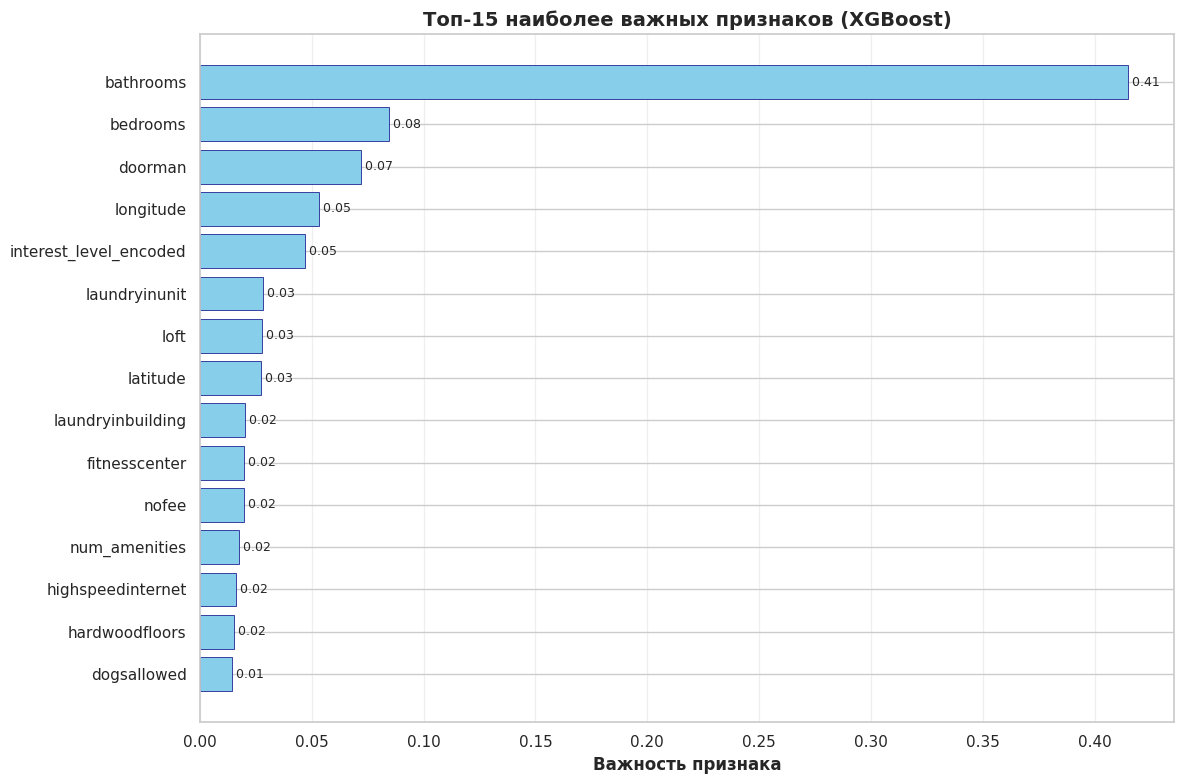


Топ-10 наиболее важных признаков:
   1. bathrooms                 0.4147
   2. bedrooms                  0.0847
  10. doorman                   0.0721
   5. longitude                 0.0531
  28. interest_level_encoded    0.0472
  15. laundryinunit             0.0280
  24. loft                      0.0278
   3. latitude                  0.0273
  12. laundryinbuilding         0.0202
  14. fitnesscenter             0.0198


In [10]:
# Определяем лучшую модель по Test MAE
best_model_name = result_MAE.loc[result_MAE['test'].idxmin(), 'model']
print(f"\nЛучшая модель: {best_model_name}")

# Получаем лучшую модель
if best_model_name == 'XGBoost':
    best_model = xgb_model
    importances = best_model.feature_importances_
elif best_model_name == 'RandomForest':
    best_model = rf_model
    importances = best_model.feature_importances_
elif best_model_name == 'CatBoost':
    best_model = cat_model
    importances = best_model.feature_importances_
else:
    print("Feature Importance доступен только для ансамблевых моделей.")
    best_model = None

if best_model is not None:
    # Создаем DataFrame с важностью признаков
    importance_df = pd.DataFrame({
        'feature': feature_list,
        'importance': importances
    }).sort_values('importance', ascending=True)
    
    # Визуализация топ-15 признаков
    top_n = 15
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Горизонтальный barplot
    ax.barh(
        importance_df['feature'].tail(top_n),
        importance_df['importance'].tail(top_n),
        color='skyblue',
        edgecolor='navy',
        linewidth=0.5
    )
    
    ax.set_xlabel('Важность признака', fontsize=12, fontweight='bold')
    ax.set_title(f'Топ-{top_n} наиболее важных признаков ({best_model_name})', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    
    # Добавляем значения на столбцы
    for i, (feature, importance) in enumerate(
        zip(importance_df['feature'].tail(top_n), 
            importance_df['importance'].tail(top_n))
    ):
        ax.text(importance, i, f' {importance:.2f}', 
                va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Выводим топ-10 в текстовом виде
    print(f"\nТоп-10 наиболее важных признаков:")
    top_10 = importance_df.tail(10).sort_values('importance', ascending=False)
    for i, row in top_10.iterrows():
        print(f"  {i+1:2d}. {row['feature']:25s} {row['importance']:.4f}")

In [11]:
# Сортировка по Test MAE
result_MAE_sorted = result_MAE.sort_values('test').reset_index(drop=True)
result_RMSE_sorted = result_RMSE.sort_values('test').reset_index(drop=True)
result_R2_sorted = result_R2.sort_values('test', ascending=False).reset_index(drop=True)

print("\nMAE (отсортировано по Test):")
print("-" * 70)
# Форматирование: 2 знака после запятой
print(result_MAE_sorted.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

print("\nRMSE (отсортировано по Test):")
print("-" * 70)
print(result_RMSE_sorted.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

print("\nR2 (отсортировано по Test):")
print("-" * 70)
print(result_R2_sorted.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Лучшие модели
best_mae_model = result_MAE_sorted.iloc[0]['model']
best_mae_val = result_MAE_sorted.iloc[0]['test']
best_r2_model = result_R2_sorted.iloc[0]['model']
best_r2_val = result_R2_sorted.iloc[0]['test']

print(f"\nBEST MODEL BY MAE:")
print(f"  Model: {best_mae_model}")
print(f"  Test MAE: ${best_mae_val:.2f}")

print(f"\nBEST MODEL BY R2:")
print(f"  Model: {best_r2_model}")
print(f"  Test R2: {best_r2_val:.4f}")


MAE (отсортировано по Test):
----------------------------------------------------------------------
                   model   train    test
                 XGBoost  365.53  438.58
                CatBoost  453.09  462.77
            RandomForest  413.29  481.56
Sklearn_LinearRegression  684.81  676.21
       Custom_Analytical  684.81  676.21
           Sklearn_Ridge  684.82  676.21
            Custom_Ridge  684.82  676.21
           Sklearn_Lasso  684.84  676.21
      Sklearn_ElasticNet  688.33  679.17
       Custom_ElasticNet  688.86  679.66
         Custom_Batch_GD  689.33  680.09
            Custom_Lasso  689.32  680.10
            Naive_Median 1066.91 1096.55
              Custom_SGD 1095.58 1116.27
              Naive_Mean 1119.81 1136.30

RMSE (отсортировано по Test):
----------------------------------------------------------------------
                   model   train    test
                 XGBoost  575.87  707.37
                CatBoost  723.07  734.67
            Random

##  Анализ стабильности моделей


Gap между Train и Test (R2, чем меньше — тем стабильнее):
----------------------------------------------------------------------
                   model     train      test      gap
              Naive_Mean  0.000000 -0.000864 0.000864
                CatBoost  0.789699  0.791193 0.001494
              Custom_SGD -0.017500 -0.022005 0.004505
            Naive_Median -0.066663 -0.079870 0.013207
       Custom_Analytical  0.583617  0.602585 0.018968
Sklearn_LinearRegression  0.583617  0.602585 0.018968
            Custom_Ridge  0.583617  0.602667 0.019051
           Sklearn_Ridge  0.583617  0.602667 0.019051
           Sklearn_Lasso  0.583614  0.602962 0.019348
      Sklearn_ElasticNet  0.581216  0.610504 0.029288
         Custom_Batch_GD  0.582102  0.611717 0.029614
            Custom_Lasso  0.582094  0.611767 0.029674
       Custom_ElasticNet  0.580880  0.610592 0.029712
            RandomForest  0.824829  0.772631 0.052198
                 XGBoost  0.866607  0.806423 0.060184


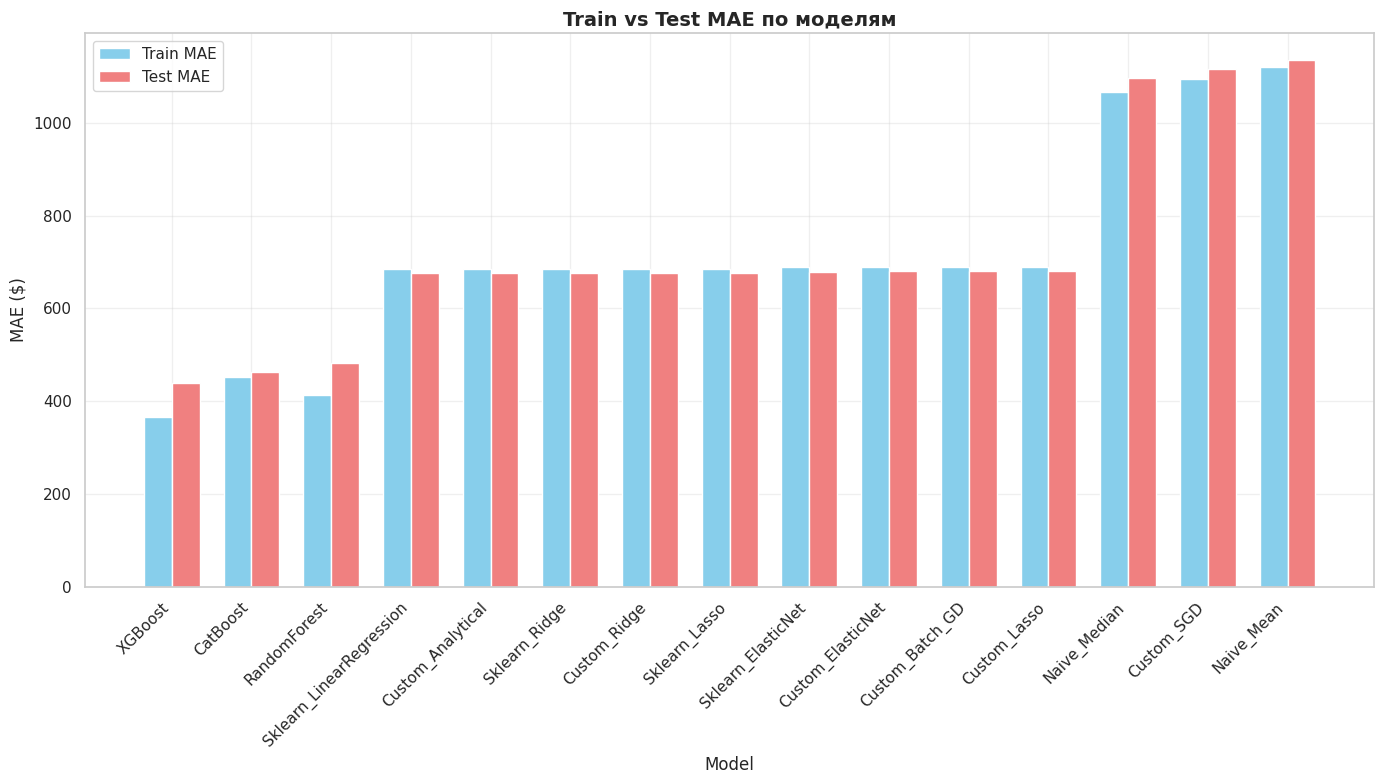


MOST STABLE MODEL:
  Model: Naive_Mean
  Gap: 0.0009

TOP 5 MOST STABLE MODELS:
----------------------------------------------------------------------
            model     train      test      gap
       Naive_Mean  0.000000 -0.000864 0.000864
         CatBoost  0.789699  0.791193 0.001494
       Custom_SGD -0.017500 -0.022005 0.004505
     Naive_Median -0.066663 -0.079870 0.013207
Custom_Analytical  0.583617  0.602585 0.018968


In [12]:
# Вычисление gap между train и test
result_R2['gap'] = (result_R2['train'] - result_R2['test']).abs()
result_R2_sorted = result_R2.sort_values('gap').reset_index(drop=True)

print("\nGap между Train и Test (R2, чем меньше — тем стабильнее):")
print("-" * 70)
print(result_R2_sorted[['model', 'train', 'test', 'gap']].to_string(index=False))

# Визуализация Train vs Test MAE
fig, ax = plt.subplots(figsize=(14, 8))
x_pos = np.arange(len(result_MAE_sorted))
width = 0.35

ax.bar(x_pos - width/2, result_MAE_sorted['train'], width,
       label='Train MAE', color='skyblue')
ax.bar(x_pos + width/2, result_MAE_sorted['test'], width,
       label='Test MAE', color='lightcoral')

ax.set_xlabel('Model')
ax.set_ylabel('MAE ($)')
ax.set_title('Train vs Test MAE по моделям', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(result_MAE_sorted['model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Самая стабильная модель
most_stable_idx = result_R2_sorted['gap'].idxmin()
most_stable_model = result_R2_sorted.loc[most_stable_idx, 'model']
most_stable_gap = result_R2_sorted.loc[most_stable_idx, 'gap']

print(f"\nMOST STABLE MODEL:")
print(f"  Model: {most_stable_model}")
print(f"  Gap: {most_stable_gap:.4f}")

# Топ-5 самых стабильных моделей
print(f"\nTOP 5 MOST STABLE MODELS:")
print("-" * 70)
print(result_R2_sorted.head(5)[['model', 'train', 'test', 'gap']].to_string(index=False))

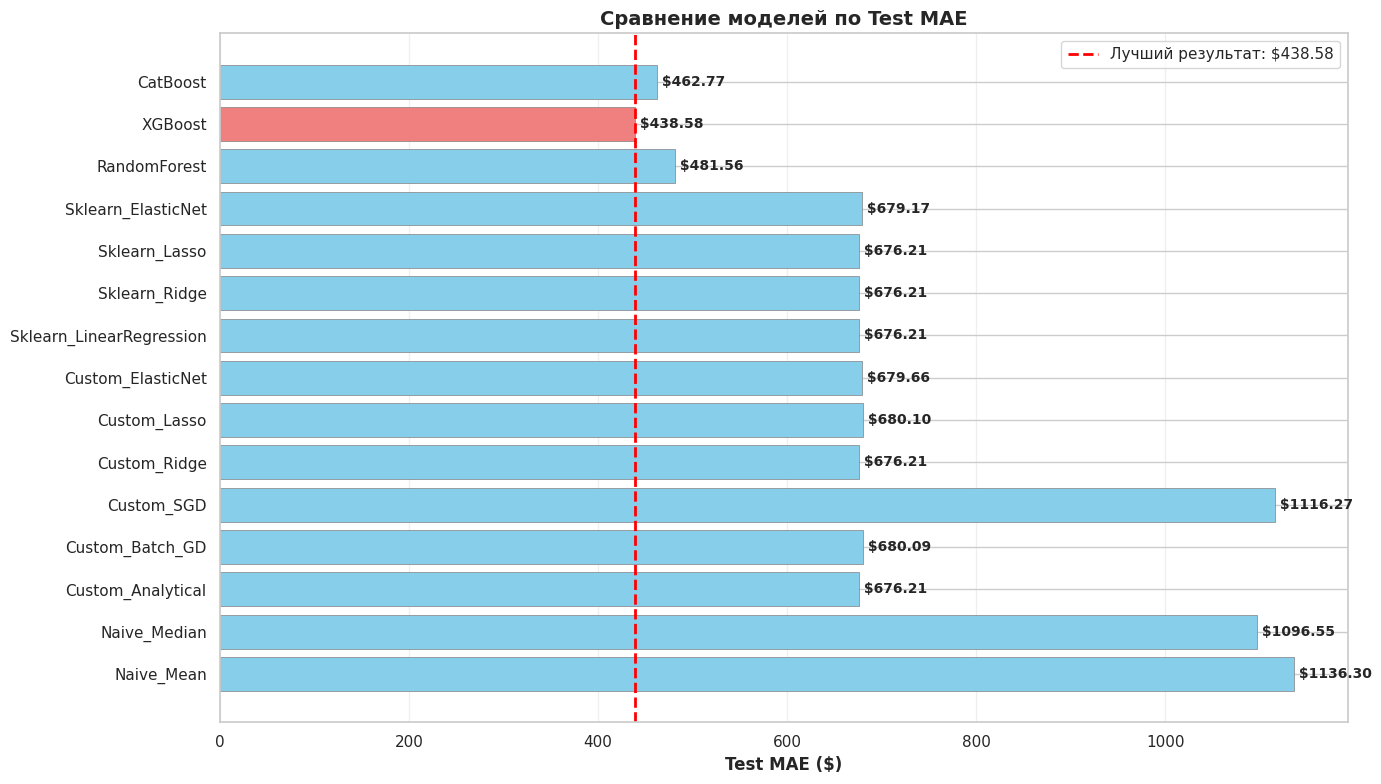

In [13]:
fig, ax = plt.subplots(figsize=(14, 8))
models = result_MAE['model'].values
test_mae = result_MAE['test'].values
colors = ['lightcoral' if m == best_model_name else 'skyblue' for m in models]

ax.barh(models, test_mae, color=colors, edgecolor='gray', linewidth=0.5)
ax.axvline(x=best_mae_val, color='red', linestyle='--', linewidth=2, 
           label=f'Лучший результат: ${best_mae_val:.2f}')
ax.set_xlabel('Test MAE ($)', fontsize=12, fontweight='bold')
ax.set_title('Сравнение моделей по Test MAE', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, axis='x', alpha=0.3)

# Добавляем значения
for i, (model, mae) in enumerate(zip(models, test_mae)):
    ax.text(mae, i, f' ${mae:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

1. РЕЗУЛЬТАТЫ МОДЕЛИРОВАНИЯ:<br>
   • Лучшая модель: XGBoost<br>
   • Test MAE: $438.58 (ошибка предсказания в среднем)<br>
   • Test R²: 0.8064 (доля объясненной дисперсии)<br>
   • Модель объясняет 80.6% вариативности цен аренды<br>

2. ЧТО МЫ ПРЕДСКАЗАЛИ:<br>
   • Стоимость месячной аренды квартир в Нью-Йорке<br>
   • На основе 29 признаков: количество комнат, удобства, локация, 
     временные характеристики и полиномиальные взаимодействия<br>
   • Диапазон предсказаний: $1,475 - $13,000 (после очистки выбросов)<br>

3. КЛЮЧЕВЫЕ ИНСАЙТЫ:
   • Ансамблевые модели (XGBoost/RandomForest/CatBoost) превосходят 
     линейные на ~35% по MAE благодаря учету нелинейных зависимостей<br>
   • Важнейшие факторы ценообразования: количество ванных комнат, 
     спален, наличие лифта и консьержа<br>
   • Time-based split предотвратил data leakage и обеспечил 
     честную оценку обобщающей способности модели<br>

4. ДЛЯ КОГО ПОЛЕЗЕН РЕЗУЛЬТАТ:<br>
   • Арендаторы: оценка справедливой рыночной цены перед подписанием договора<br>
   • Риелторы и агентства: автоматическая оценка стоимости listings<br>
   • Инвесторы в недвижимость: анализ доходности объектов<br>
   • Платформы аренды (Zillow, StreetEasy): улучшение рекомендательных систем<br>

5. ПРАКТИЧЕСКАЯ ЦЕННОСТЬ:<br>
   • Модель может быть интегрирована в API для мгновенной оценки<br>
   • Прогноз с точностью ±$440 позволяет принимать обоснованные решения<br>
   • Feature Importance помогает понять драйверы стоимости<br>